# Gemma 4 26B — 사전학습 모델 기본 성능 리포트

**모델:** `gemma4:26b` (Gemma 4 27B, Ollama 로컬 실행 — CPU 전용 / LG Gram)  
**작성자:** woochul  
**실험 일시:** 2026-05-08  
**데이터셋:** AI 생성 이미지 101장 / 실제 인물 사진 249장 (총 350장)  
**태스크:** AI 생성 이미지 탐지 (이진 분류 — AI vs Real)  
**실행 환경:** Ollama 로컬, 이미지 512×512 리사이즈, temperature=0.1, CPU 전용

---

### 평가 목표치
| 지표 | 목표 | 방향 |
|---|---|---|
| Accuracy | 70% 이상 | ↑ |
| Precision | 75% 이상 | ↑ |
| Recall ★ | 75% 이상 (핵심) | ↑ |
| F1 Score | 70% 이상 | ↑ |
| FPR | 20% 이하 | ↓ |
| Avg Inference Time | 90초 이하 (CPU 전용) | ↓ |

In [1]:
import subprocess, sys
try:
    import matplotlib
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib'], check=True)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family']      = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

COLOR_PASS    = '#2ecc71'
COLOR_FAIL    = '#e74c3c'
COLOR_G26B    = '#FF6F00'   # 주황 — 26B
COLOR_G12B    = '#8e44ad'   # 보라 — 12B
COLOR_VIT     = '#3498db'   # 파랑 — ViT
COLOR_TARGET  = '#f39c12'
COLOR_AI      = '#e74c3c'
COLOR_REAL    = '#3498db'

BENCH_DIR = os.path.dirname(os.path.abspath('__file__'))

TARGET = {
    'accuracy' : 70.0,
    'precision': 75.0,
    'recall'   : 75.0,
    'f1'       : 70.0,
    'fpr'      : 20.0,
    'avg_time' : 90.0,   # CPU 전용 목표
}

# ── 26B raw 데이터 로드 ──
raw_path = os.path.join(BENCH_DIR, 'gemma4_26b_raw_20260508_135144.csv')
df_raw = pd.read_csv(raw_path)
df_raw['true_label'] = pd.to_numeric(df_raw['true_label'], errors='coerce')
df_raw['pred_label'] = pd.to_numeric(df_raw['pred_label'], errors='coerce')
df_raw['confidence'] = pd.to_numeric(df_raw['confidence'], errors='coerce')
df_raw['elapsed']    = pd.to_numeric(df_raw['elapsed'],    errors='coerce')

# ── 지표 계산 ──
df_v = df_raw[df_raw['verdict'].isin(['AI_GENERATED', 'REAL'])].copy()
y_true = df_v['true_label'].astype(int)
y_pred = df_v['pred_label'].astype(int)

tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())
total = tp + fp + fn + tn

accuracy  = (tp + tn) / total * 100
precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
fpr       = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
avg_time  = df_raw['elapsed'].mean()

m = {
    'accuracy': accuracy, 'precision': precision, 'recall': recall,
    'f1': f1, 'fpr': fpr, 'avg_time': avg_time,
    'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'n_total': total,
}

# ── 비교 기준값 ──
VIT_REF = {
    'model': 'haywoodsloan/ai-image-detector-deploy',
    'accuracy': 88.25, 'precision': 75.86, 'recall': 87.13,
    'f1': 81.11, 'fpr': 11.29, 'avg_time': 0.828,
    'tp': 88, 'fp': 28, 'fn': 13, 'tn': 220,
}
G12B_REF = {
    'model': 'gemma4:e4b (12B)',
    'accuracy': 65.33, 'precision': 36.11, 'recall': 25.74,
    'f1': 30.06, 'fpr': 18.55, 'avg_time': 24.179,
    'tp': 26, 'fp': 46, 'fn': 75, 'tn': 202,
}

print(f'[26B Raw]  rows={len(df_raw)}, valid={len(df_v)}')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}  (N={total})')
print(f'Accuracy={accuracy:.2f}%  Precision={precision:.2f}%  Recall={recall:.2f}%')
print(f'F1={f1:.2f}%  FPR={fpr:.2f}%  Avg Time={avg_time:.2f}s')

[26B Raw]  rows=350, valid=348
TP=66  FP=124  FN=35  TN=123  (N=348)
Accuracy=54.31%  Precision=34.74%  Recall=65.35%
F1=45.36%  FPR=50.20%  Avg Time=192.05s


---
## 1. 핵심 지표 요약

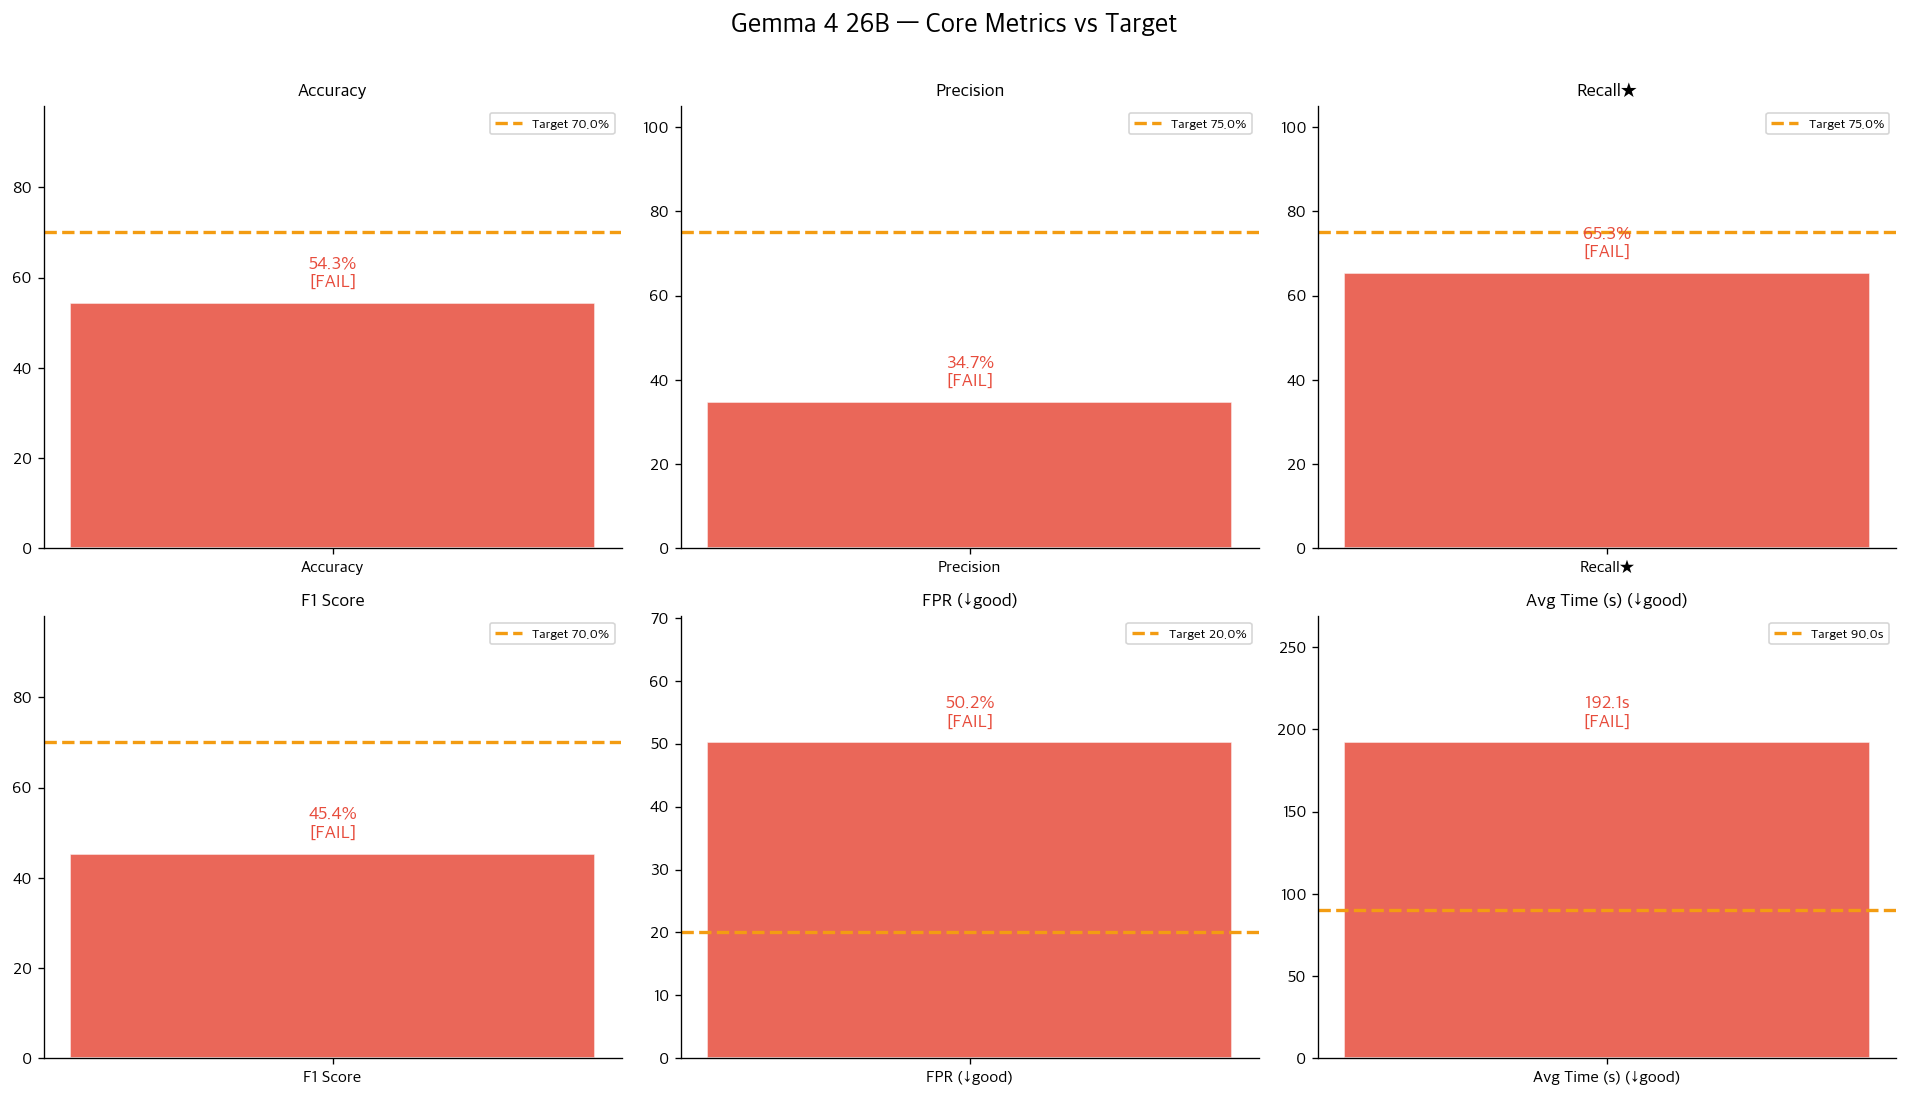

In [2]:
metrics       = ['accuracy', 'precision', 'recall', 'f1', 'fpr', 'avg_time']
metric_labels = ['Accuracy', 'Precision', 'Recall★', 'F1 Score', 'FPR (↓good)', 'Avg Time (s) (↓good)']
lower_better  = [False, False, False, False, True, True]

vals    = [m[k] for k in metrics]
targets = [TARGET[k] for k in metrics]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Gemma 4 26B — Core Metrics vs Target', fontsize=16, fontweight='bold', y=1.01)

for ax, metric, label, val, target, lower in zip(
        axes.flat, metrics, metric_labels, vals, targets, lower_better):

    ok    = (val <= target) if lower else (val >= target)
    color = COLOR_PASS if ok else COLOR_FAIL
    unit  = 's' if 'time' in metric else '%'

    ax.bar([label], [val], color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(target, color=COLOR_TARGET, linestyle='--', linewidth=2,
               label=f'Target {target}{unit}')
    ax.set_ylim(0, max(val, target) * 1.4)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

    badge = 'PASS' if ok else 'FAIL'
    ax.text(0, val + max(val, target) * 0.05,
            f'{val:.1f}{unit}\n[{badge}]', ha='center', fontsize=11,
            fontweight='bold', color=COLOR_PASS if ok else COLOR_FAIL)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_core_metrics_nb.png'),
            bbox_inches='tight', dpi=150)
plt.show()

---
## 2. 목표치 달성 현황표

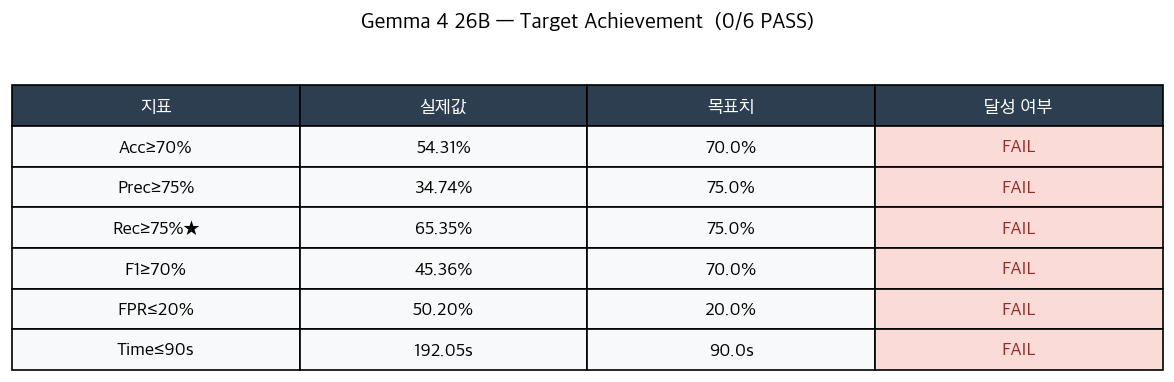

총 0/6 항목 목표 달성


In [3]:
check_cfg = [
    ('Acc≥70%',    'accuracy',  70.0, False),
    ('Prec≥75%',   'precision', 75.0, False),
    ('Rec≥75%★',   'recall',    75.0, False),
    ('F1≥70%',     'f1',        70.0, False),
    ('FPR≤20%',    'fpr',       20.0, True),
    ('Time≤90s',   'avg_time',  90.0, True),
]

row_data = []
pass_cnt = 0
for col_label, metric, tgt, lower in check_cfg:
    val = m[metric]
    ok  = (val <= tgt) if lower else (val >= tgt)
    pass_cnt += int(ok)
    unit = 's' if 'time' in metric else '%'
    row_data.append([col_label, f'{val:.2f}{unit}', f'{tgt}{unit}', 'PASS' if ok else 'FAIL'])

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
tbl = ax.table(cellText=row_data,
               colLabels=['지표', '실제값', '목표치', '달성 여부'],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.2)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 3:
        txt = cell.get_text().get_text()
        if txt == 'PASS':
            cell.set_facecolor('#d5f5e3')
            cell.set_text_props(color='#1e8449', fontweight='bold')
        elif txt == 'FAIL':
            cell.set_facecolor('#fadbd8')
            cell.set_text_props(color='#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')

fig.suptitle(f'Gemma 4 26B — Target Achievement  ({pass_cnt}/6 PASS)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_target_table.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print(f'총 {pass_cnt}/6 항목 목표 달성')

---
## 3. 혼동 행렬 (Confusion Matrix)

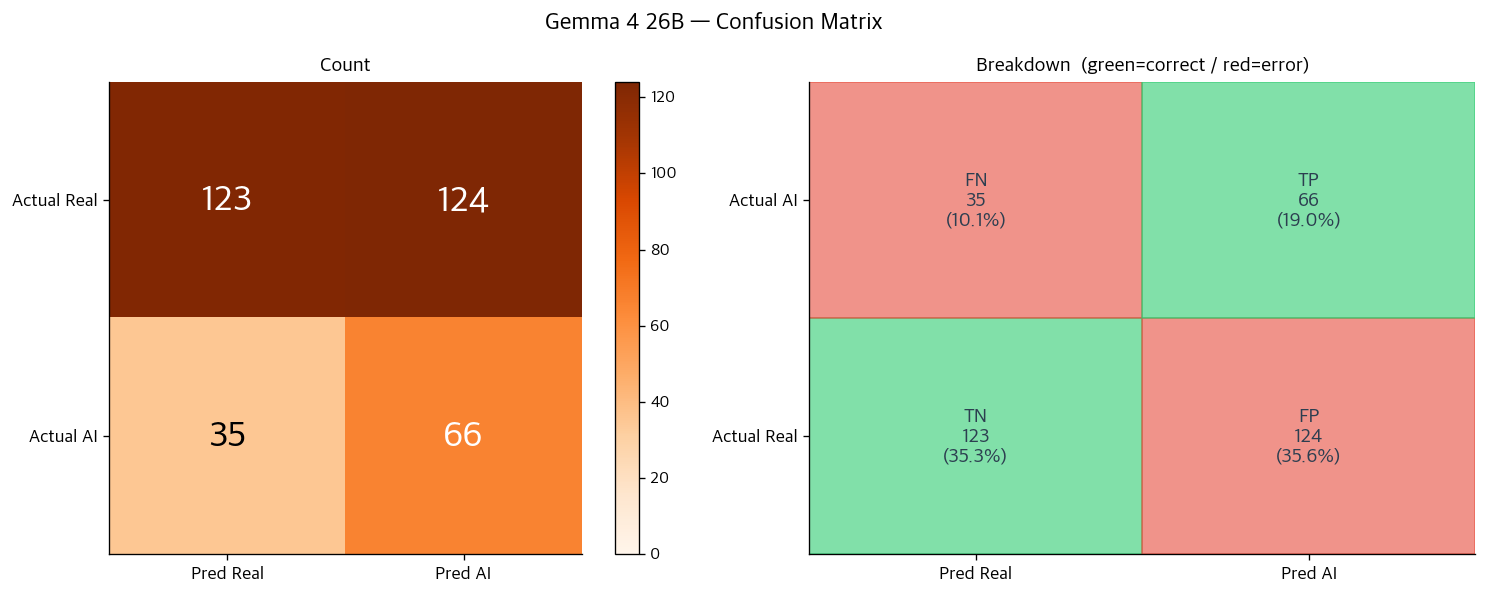

TP (AI 정탐)   : 66  (65.3% of AI images)
FN (AI 미탐)   : 35  (34.7% of AI images)  ← AI를 놓침
FP (Real 오탐) : 124  (50.2% of Real images) ← Real을 AI로 오판
TN (Real 정탐) : 123  (49.8% of Real images)


In [4]:
cm = np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gemma 4 26B — Confusion Matrix', fontsize=14, fontweight='bold')

# 왼쪽: 절대 수치
ax = axes[0]
im = ax.imshow(cm, cmap='Oranges', vmin=0)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Real', 'Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real', 'Actual AI'], fontsize=11)
ax.set_title('Count', fontsize=12, fontweight='bold')
for r in range(2):
    for c in range(2):
        ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                fontsize=22, fontweight='bold',
                color='white' if cm[r, c] > cm.max() * 0.5 else 'black')
plt.colorbar(im, ax=ax)

# 오른쪽: 비율 breakdown
ax = axes[1]
labels_pct = np.array([
    [f'TN\n{tn}\n({tn/total*100:.1f}%)', f'FP\n{fp}\n({fp/total*100:.1f}%)'],
    [f'FN\n{fn}\n({fn/total*100:.1f}%)', f'TP\n{tp}\n({tp/total*100:.1f}%)']
])
colors_map = np.array([[COLOR_PASS, COLOR_FAIL], [COLOR_FAIL, COLOR_PASS]])
for r in range(2):
    for c in range(2):
        rect = plt.Rectangle([c - 0.5, r - 0.5], 1, 1,
                              color=colors_map[r, c], alpha=0.6)
        ax.add_patch(rect)
        ax.text(c, r, labels_pct[r, c], ha='center', va='center',
                fontsize=12, fontweight='bold', color='#2c3e50')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Real', 'Pred AI'], fontsize=11)
ax.set_yticklabels(['Actual Real', 'Actual AI'], fontsize=11)
ax.set_title('Breakdown  (green=correct / red=error)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_confusion_nb.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print(f'TP (AI 정탐)   : {tp}  ({tp/(tp+fn)*100:.1f}% of AI images)')
print(f'FN (AI 미탐)   : {fn}  ({fn/(tp+fn)*100:.1f}% of AI images)  ← AI를 놓침')
print(f'FP (Real 오탐) : {fp}  ({fp/(fp+tn)*100:.1f}% of Real images) ← Real을 AI로 오판')
print(f'TN (Real 정탐) : {tn}  ({tn/(fp+tn)*100:.1f}% of Real images)')

---
## 4. 클래스별 성능 분석

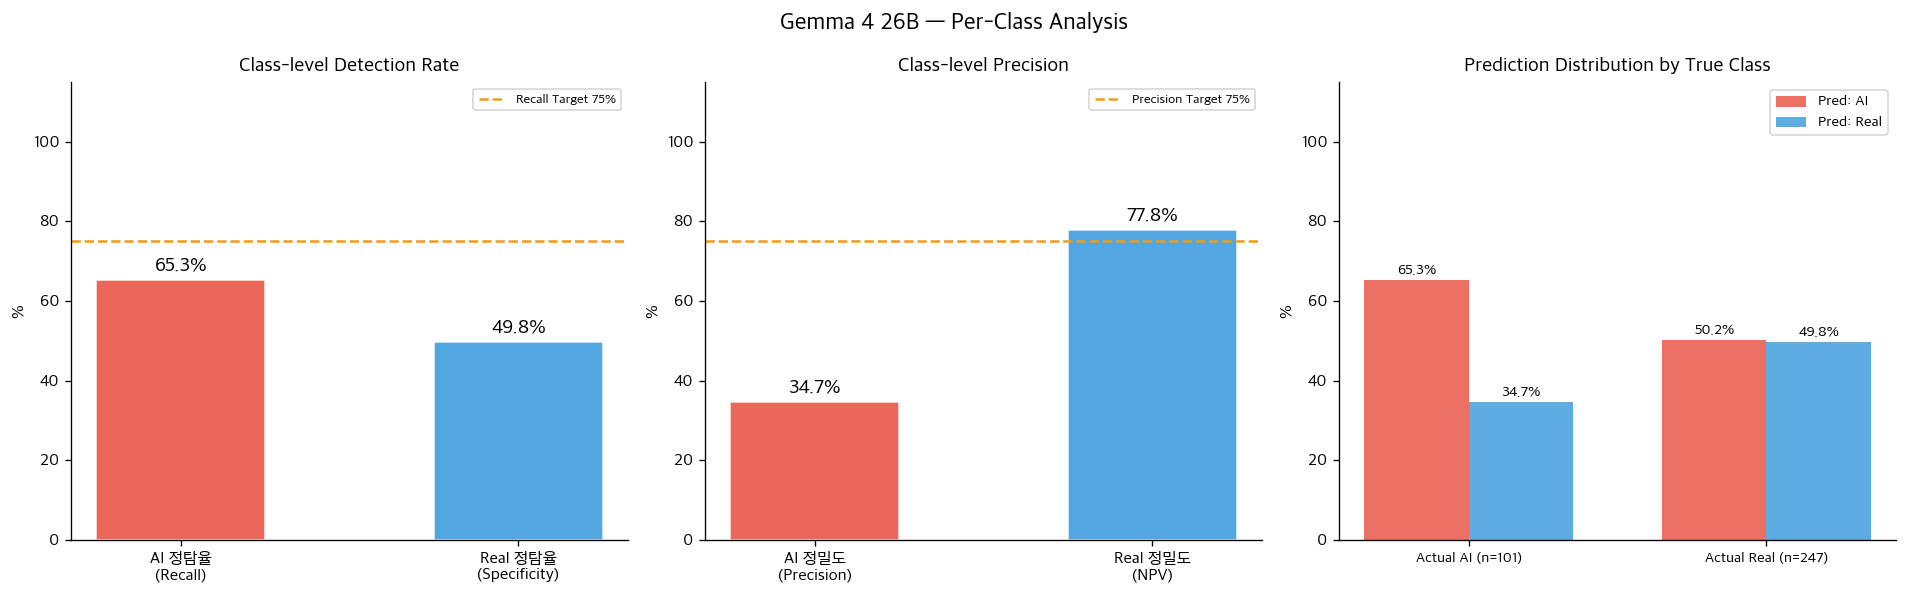


[AI 이미지 101장]
  AI로 정탐 (TP): 66장 (65.3%)
  Real로 오탐 (FN): 35장 (34.7%)

[Real 이미지 247장]
  Real로 정탐 (TN): 123장 (49.8%)
  AI로 오탐 (FP): 124장 (50.2%)  ← 26B의 핵심 문제


In [5]:
n_ai   = tp + fn
n_real = fp + tn

ai_recall   = tp / n_ai   * 100
real_recall = tn / n_real * 100
ai_prec     = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
real_prec   = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gemma 4 26B — Per-Class Analysis', fontsize=14, fontweight='bold')

# 1) 클래스별 정탐율
ax = axes[0]
cats  = ['AI 정탐율\n(Recall)', 'Real 정탐율\n(Specificity)']
rates = [ai_recall, real_recall]
bars  = ax.bar(cats, rates, color=[COLOR_AI, COLOR_REAL], alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(75, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label='Recall Target 75%')
ax.set_ylim(0, 115); ax.set_ylabel('%')
ax.set_title('Class-level Detection Rate', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# 2) 클래스별 정밀도
ax = axes[1]
cats2 = ['AI 정밀도\n(Precision)', 'Real 정밀도\n(NPV)']
precs = [ai_prec, real_prec]
bars2 = ax.bar(cats2, precs, color=[COLOR_AI, COLOR_REAL], alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(75, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label='Precision Target 75%')
ax.set_ylim(0, 115); ax.set_ylabel('%')
ax.set_title('Class-level Precision', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars2, precs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# 3) 예측 분포
ax = axes[2]
ai_pred_ai   = tp / n_ai   * 100
ai_pred_real = fn / n_ai   * 100
re_pred_ai   = fp / n_real * 100
re_pred_real = tn / n_real * 100

x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [ai_pred_ai,   re_pred_ai],   w, label='Pred: AI',   color=COLOR_AI,   alpha=0.8)
b2 = ax.bar(x + w/2, [ai_pred_real, re_pred_real], w, label='Pred: Real', color=COLOR_REAL, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'Actual AI (n={n_ai})', f'Actual Real (n={n_real})'], fontsize=9)
ax.set_ylim(0, 115); ax.set_ylabel('%')
ax.set_title('Prediction Distribution by True Class', fontweight='bold')
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            f'{h:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_per_class.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print(f'\n[AI 이미지 {n_ai}장]')
print(f'  AI로 정탐 (TP): {tp}장 ({ai_recall:.1f}%)')
print(f'  Real로 오탐 (FN): {fn}장 ({ai_pred_real:.1f}%)')
print(f'\n[Real 이미지 {n_real}장]')
print(f'  Real로 정탐 (TN): {tn}장 ({real_recall:.1f}%)')
print(f'  AI로 오탐 (FP): {fp}장 ({re_pred_ai:.1f}%)  ← 26B의 핵심 문제')

---
## 5. 신뢰도(Confidence) 분포 분석

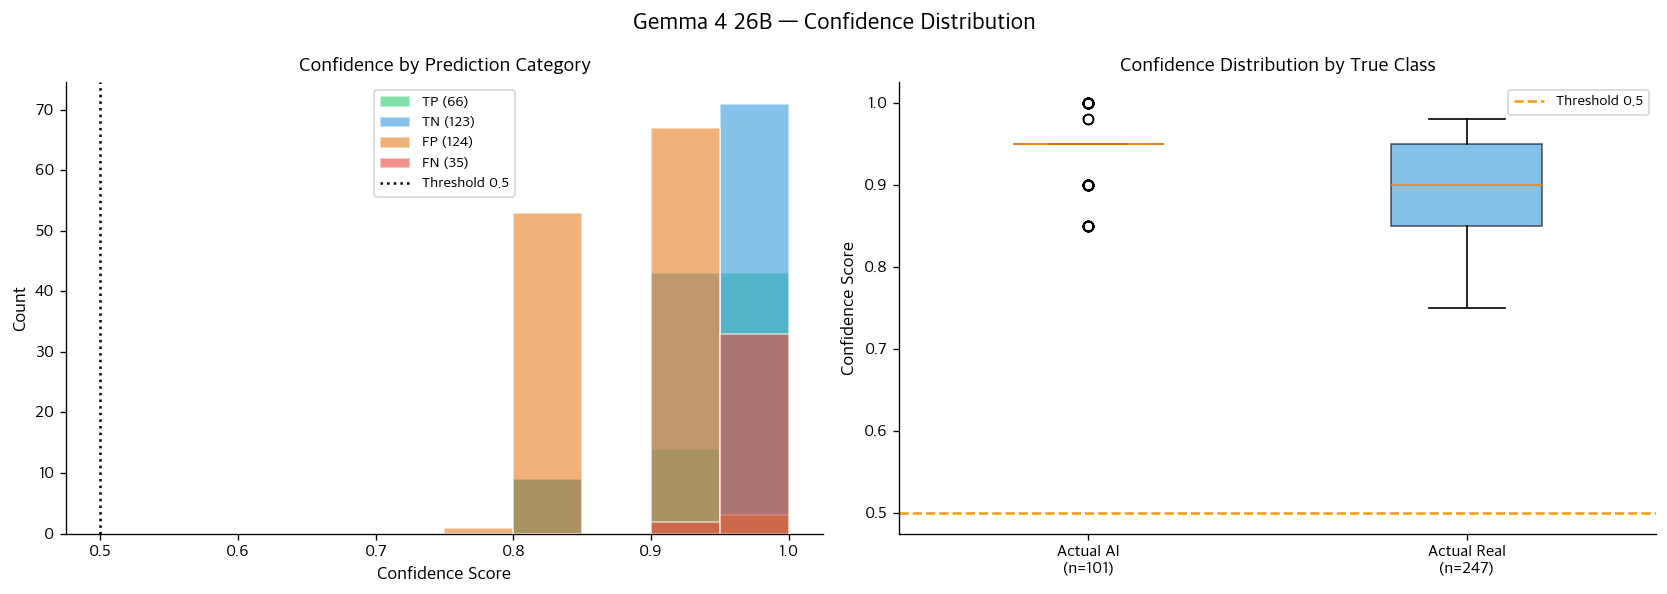

AI 이미지  평균 confidence: 0.943  (std=0.042)
Real 이미지 평균 confidence: 0.901  (std=0.041)


In [6]:
df_v2 = df_v.copy()
df_v2['category'] = df_v2.apply(
    lambda r: ('TP' if r.pred_label==1 else 'FN') if r.true_label==1
              else ('FP' if r.pred_label==1 else 'TN'), axis=1
)
cat_colors = {'TP': '#2ecc71', 'TN': '#3498db', 'FP': '#e67e22', 'FN': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gemma 4 26B — Confidence Distribution', fontsize=14, fontweight='bold')

# 카테고리별 히스토그램
ax = axes[0]
for cat in ['TP', 'TN', 'FP', 'FN']:
    data = df_v2[df_v2['category'] == cat]['confidence']
    if len(data) > 0:
        n = len(data)
        ax.hist(data, bins=10, range=(0.5, 1.0), alpha=0.6,
                color=cat_colors[cat], label=f'{cat} ({n})', edgecolor='white')
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='Threshold 0.5')
ax.set_xlabel('Confidence Score', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Confidence by Prediction Category', fontweight='bold')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
ai_conf   = df_v2[df_v2['true_label'] == 1]['confidence']
real_conf = df_v2[df_v2['true_label'] == 0]['confidence']
bp = ax.boxplot([ai_conf, real_conf], patch_artist=True,
                labels=[f'Actual AI\n(n={len(ai_conf)})', f'Actual Real\n(n={len(real_conf)})'],
                widths=0.4)
for patch, color in zip(bp['boxes'], [COLOR_AI, COLOR_REAL]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(0.5, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_ylabel('Confidence Score', fontsize=11)
ax.set_title('Confidence Distribution by True Class', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_confidence_nb.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print(f'AI 이미지  평균 confidence: {ai_conf.mean():.3f}  (std={ai_conf.std():.3f})')
print(f'Real 이미지 평균 confidence: {real_conf.mean():.3f}  (std={real_conf.std():.3f})')

---
## 6. 추론 시간 분석

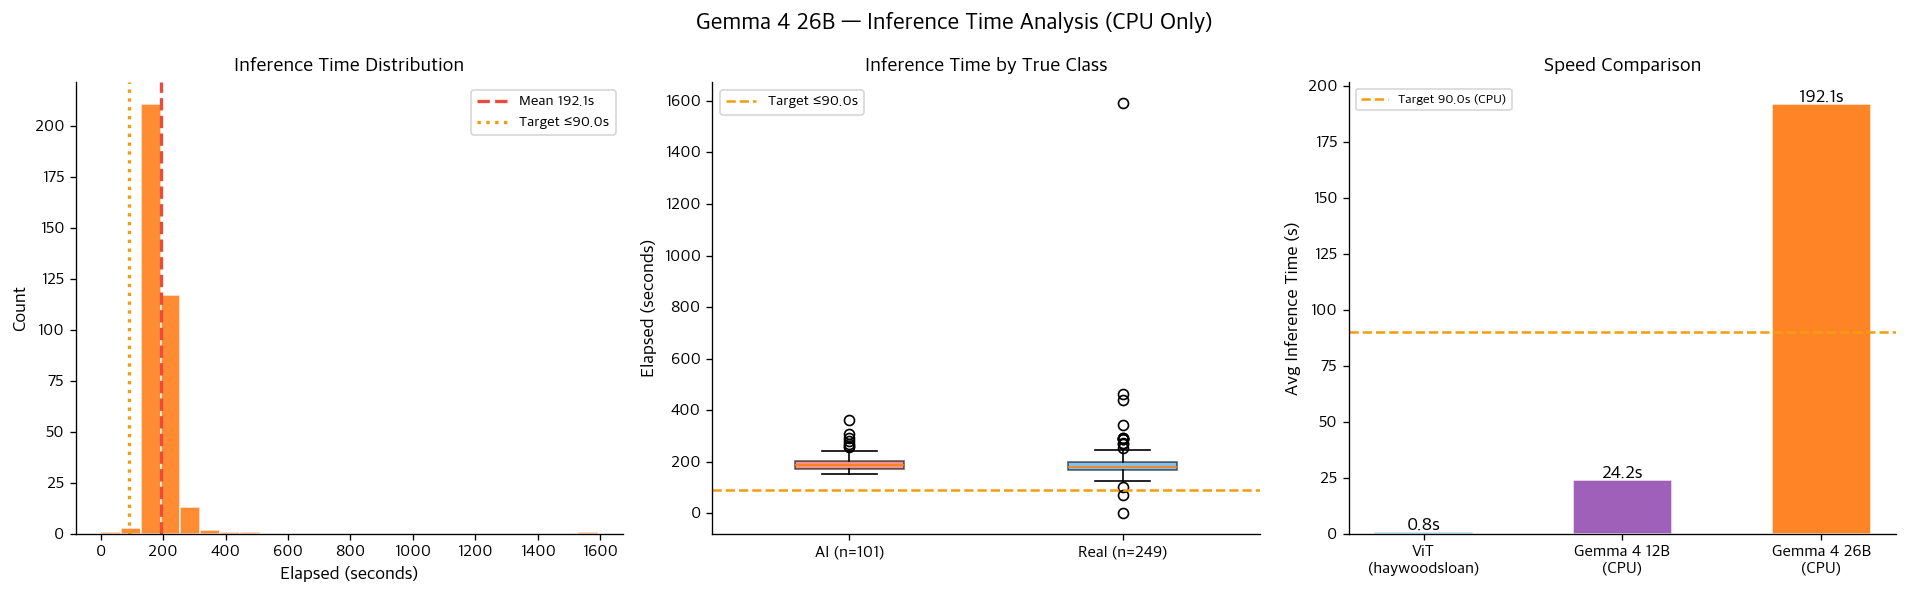

Avg time: 192.05s  (median=182.91s)
Min: 0.03s  Max: 1593.75s
ViT 대비 232배 느림  /  12B 대비 7.9배 느림


In [7]:
df_t = df_raw.dropna(subset=['elapsed']).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gemma 4 26B — Inference Time Analysis (CPU Only)', fontsize=14, fontweight='bold')

# 1) 전체 히스토그램
ax = axes[0]
ax.hist(df_t['elapsed'], bins=25, color=COLOR_G26B, alpha=0.8, edgecolor='white')
ax.axvline(df_t['elapsed'].mean(), color=COLOR_FAIL, linestyle='--',
           linewidth=2, label=f'Mean {df_t["elapsed"].mean():.1f}s')
ax.axvline(TARGET['avg_time'], color=COLOR_TARGET, linestyle=':',
           linewidth=2, label=f'Target ≤{TARGET["avg_time"]}s')
ax.set_xlabel('Elapsed (seconds)', fontsize=11); ax.set_ylabel('Count', fontsize=11)
ax.set_title('Inference Time Distribution', fontweight='bold')
ax.legend(fontsize=9)

# 2) AI vs Real 박스플롯
ax = axes[1]
ai_t   = df_t[df_t['true_label'] == 1]['elapsed']
real_t = df_t[df_t['true_label'] == 0]['elapsed']
bp = ax.boxplot([ai_t, real_t], patch_artist=True,
                labels=[f'AI (n={len(ai_t)})', f'Real (n={len(real_t)})'],
                widths=0.4)
for patch, color in zip(bp['boxes'], [COLOR_AI, COLOR_REAL]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(TARGET['avg_time'], color=COLOR_TARGET, linestyle='--',
           linewidth=1.5, label=f'Target ≤{TARGET["avg_time"]}s')
ax.set_ylabel('Elapsed (seconds)', fontsize=11)
ax.set_title('Inference Time by True Class', fontweight='bold')
ax.legend(fontsize=9)

# 3) ViT vs 12B vs 26B 속도 비교
ax = axes[2]
models_cmp = ['ViT\n(haywoodsloan)', 'Gemma 4 12B\n(CPU)', 'Gemma 4 26B\n(CPU)']
times_cmp  = [VIT_REF['avg_time'], G12B_REF['avg_time'], avg_time]
colors_cmp = [COLOR_VIT, COLOR_G12B, COLOR_G26B]
bars_cmp   = ax.bar(models_cmp, times_cmp, color=colors_cmp, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(TARGET['avg_time'], color=COLOR_TARGET, linestyle='--',
           linewidth=1.5, label=f'Target {TARGET["avg_time"]}s (CPU)')
ax.set_ylabel('Avg Inference Time (s)', fontsize=11)
ax.set_title('Speed Comparison', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars_cmp, times_cmp):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}s', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_time.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print(f'Avg time: {df_t["elapsed"].mean():.2f}s  (median={df_t["elapsed"].median():.2f}s)')
print(f'Min: {df_t["elapsed"].min():.2f}s  Max: {df_t["elapsed"].max():.2f}s')
print(f'ViT 대비 {avg_time/VIT_REF["avg_time"]:.0f}배 느림  /  12B 대비 {avg_time/G12B_REF["avg_time"]:.1f}배 느림')

---
## 7. 오분류 패턴 분석 (FN & FP)

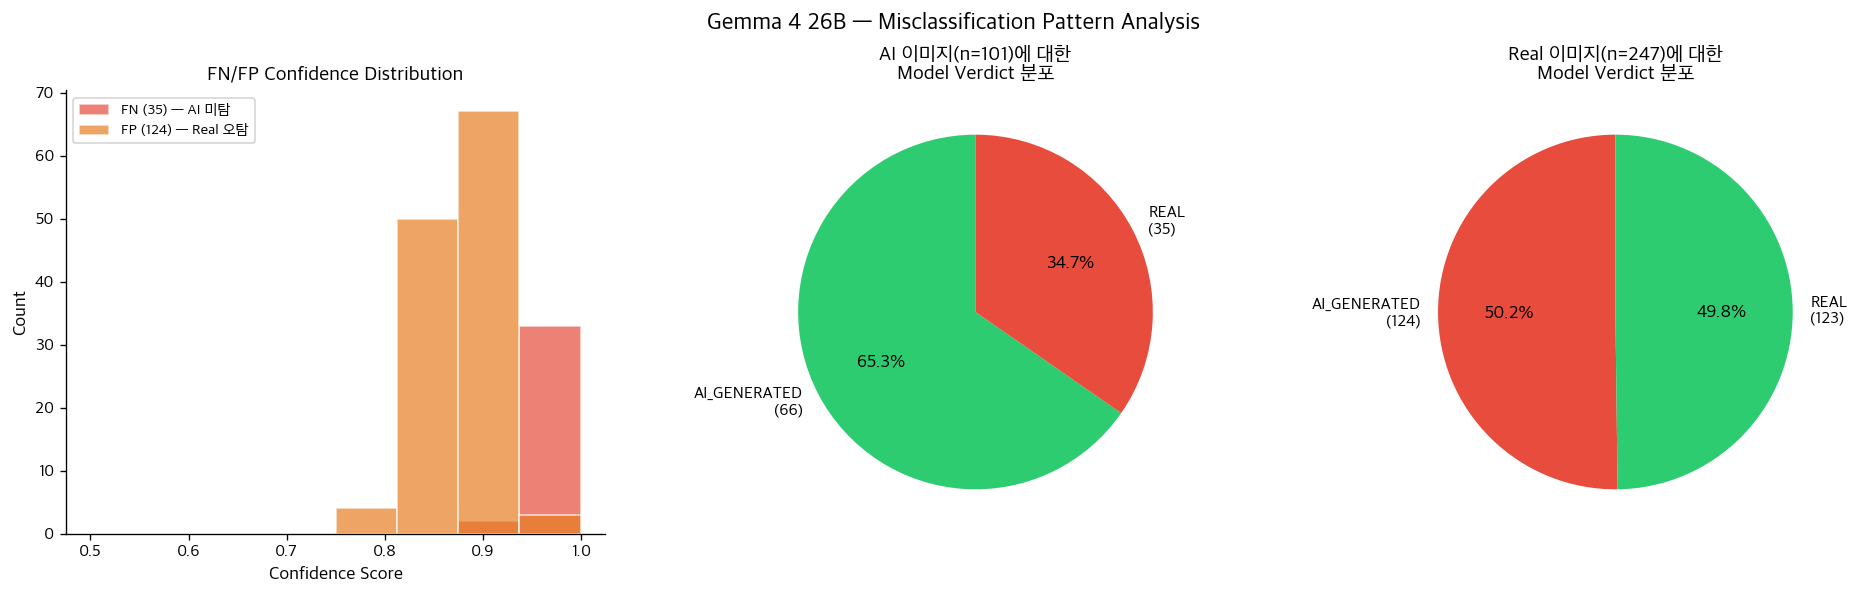


[FP 샘플 — Real 이미지인데 AI로 오판한 예시 3건]
  C:\Users\chul3\github\Last_Project_test\data\test_dataset\real\real_0002.jpg: conf=0.85
    이유: 피부 질감이 지나치게 매끄럽고 조명이 닿는 부분이 인위적으로 밝게 빛나는 수채화 같은 느낌이 있음
  C:\Users\chul3\github\Last_Project_test\data\test_dataset\real\real_0003.jpg: conf=0.85
    이유: 연기와 머리카락, 피부의 경계가 지나치게 매끄럽고 연기의 질감이 다소 수채화처럼 부드러운 느낌을 줌
  C:\Users\chul3\github\Last_Project_test\data\test_dataset\real\real_0004.jpg: conf=0.90
    이유: 피부 질감이 지나치게 매끄럽고 손가락의 형태가 부자연스럽게 뭉개져 있음


In [8]:
fn_rows = df_v2[df_v2['category'] == 'FN'].reset_index(drop=True)
fp_rows = df_v2[df_v2['category'] == 'FP'].reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gemma 4 26B — Misclassification Pattern Analysis', fontsize=14, fontweight='bold')

# 1) FN/FP 신뢰도 분포
ax = axes[0]
if len(fn_rows) > 0:
    ax.hist(fn_rows['confidence'], bins=8, range=(0.5,1.0), alpha=0.7,
            color=COLOR_FAIL, label=f'FN ({len(fn_rows)}) — AI 미탐', edgecolor='white')
if len(fp_rows) > 0:
    ax.hist(fp_rows['confidence'], bins=8, range=(0.5,1.0), alpha=0.7,
            color='#e67e22', label=f'FP ({len(fp_rows)}) — Real 오탐', edgecolor='white')
ax.set_xlabel('Confidence Score', fontsize=11); ax.set_ylabel('Count', fontsize=11)
ax.set_title('FN/FP Confidence Distribution', fontweight='bold')
ax.legend(fontsize=9)

# 2) AI 이미지 verdict 분포
ax = axes[1]
ai_verdict = df_v2[df_v2['true_label'] == 1]['verdict'].value_counts()
colors_v = [COLOR_PASS if v == 'AI_GENERATED' else COLOR_FAIL for v in ai_verdict.index]
wedges, texts, autotexts = ax.pie(
    ai_verdict.values,
    labels=[f'{v}\n({c})' for v, c in ai_verdict.items()],
    colors=colors_v, autopct='%1.1f%%', startangle=90)
for at in autotexts: at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title(f'AI 이미지(n={n_ai})에 대한\nModel Verdict 분포', fontweight='bold')

# 3) Real 이미지 verdict 분포
ax = axes[2]
real_verdict = df_v2[df_v2['true_label'] == 0]['verdict'].value_counts()
colors_rv = [COLOR_FAIL if v == 'AI_GENERATED' else COLOR_PASS for v in real_verdict.index]
wedges2, texts2, autotexts2 = ax.pie(
    real_verdict.values,
    labels=[f'{v}\n({c})' for v, c in real_verdict.items()],
    colors=colors_rv, autopct='%1.1f%%', startangle=90)
for at in autotexts2: at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title(f'Real 이미지(n={n_real})에 대한\nModel Verdict 분포', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_misclassification.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print(f'\n[FP 샘플 — Real 이미지인데 AI로 오판한 예시 3건]')
for _, row in fp_rows.head(3).iterrows():
    fname = os.path.basename(str(row['image_path']))
    print(f'  {fname}: conf={row.confidence:.2f}')
    print(f'    이유: {str(row.reason)[:100]}')

---
## 8. Gemma 4 12B vs 26B 직접 비교

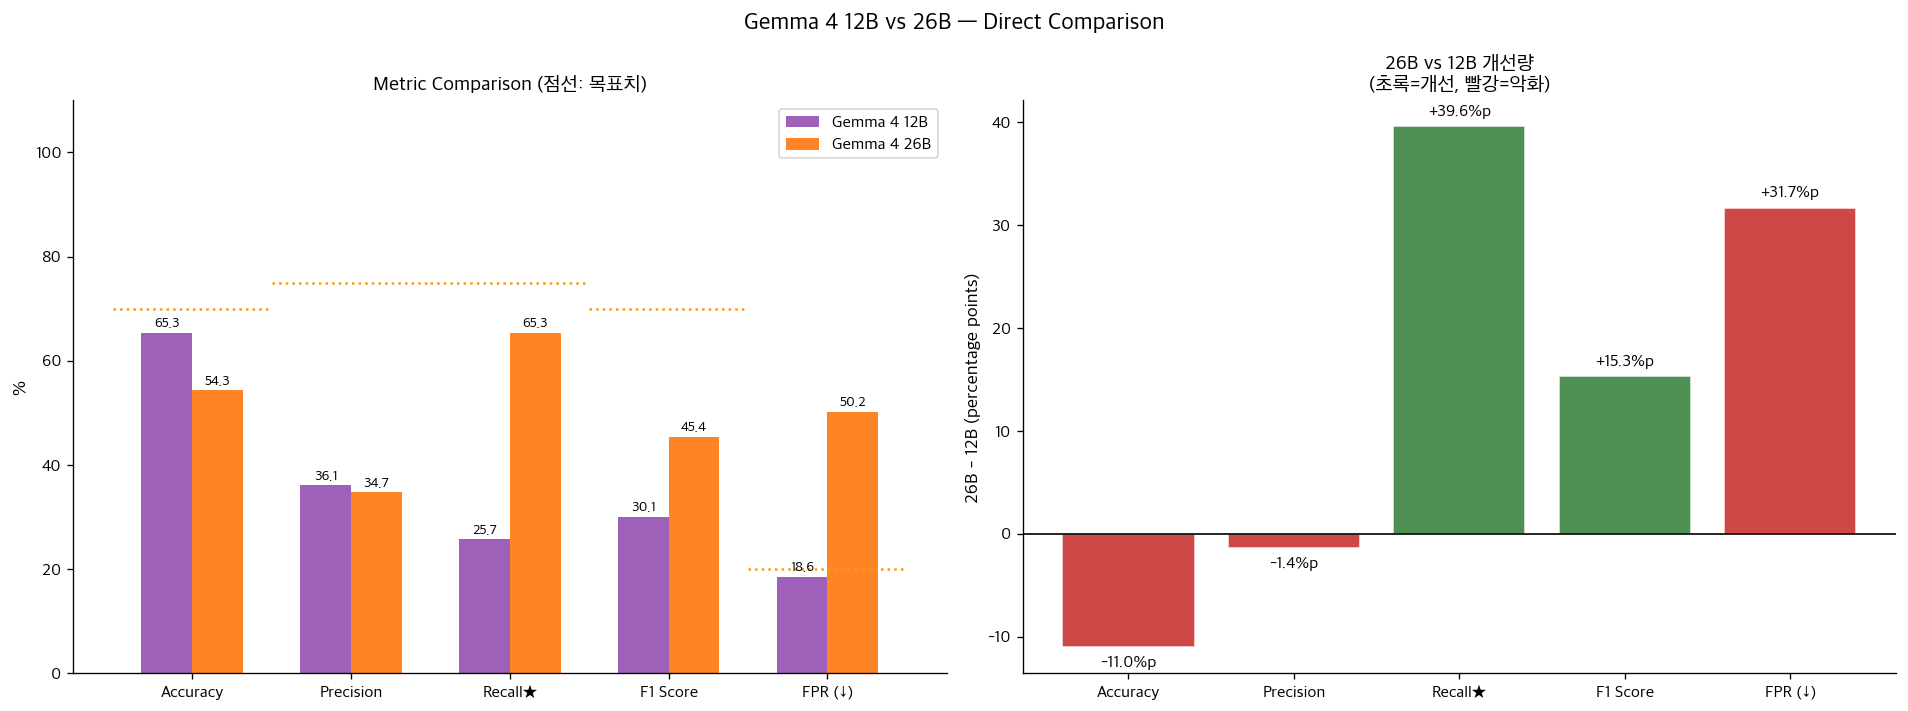


[12B vs 26B 비교]
  Accuracy      : 12B=65.3%  26B=54.3%  (-11.0%p worse)
  Precision     : 12B=36.1%  26B=34.7%  (-1.4%p worse)
  Recall★       : 12B=25.7%  26B=65.3%  (+39.6%p better)
  F1 Score      : 12B=30.1%  26B=45.4%  (+15.3%p better)
  FPR (↓)       : 12B=18.6%  26B=50.2%  (+31.7%p worse)


In [9]:
cmp_metrics = ['accuracy', 'precision', 'recall', 'f1', 'fpr']
cmp_labels  = ['Accuracy', 'Precision', 'Recall★', 'F1 Score', 'FPR (↓)']

g12b_vals = [G12B_REF[k] for k in cmp_metrics]
g26b_vals = [m[k]        for k in cmp_metrics]
tgt_vals  = [TARGET[k]   for k in cmp_metrics]

x = np.arange(len(cmp_metrics)); w = 0.32

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gemma 4 12B vs 26B — Direct Comparison', fontsize=14, fontweight='bold')

# 막대 비교
ax = axes[0]
b12 = ax.bar(x - w/2, g12b_vals, w, label='Gemma 4 12B', color=COLOR_G12B, alpha=0.85)
b26 = ax.bar(x + w/2, g26b_vals, w, label='Gemma 4 26B', color=COLOR_G26B, alpha=0.85)
for xi, tv in zip(x, tgt_vals):
    ax.hlines(tv, xi - 0.5, xi + 0.5, colors=COLOR_TARGET, linestyles=':', linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(cmp_labels, fontsize=10)
ax.set_ylim(0, 110); ax.set_ylabel('%', fontsize=11)
ax.set_title('Metric Comparison (점선: 목표치)', fontweight='bold')
ax.legend(fontsize=10)
for bar in list(b12) + list(b26):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8.5)

# 개선율 (26B - 12B)
ax = axes[1]
deltas = [g26b_vals[i] - g12b_vals[i] for i in range(len(cmp_metrics))]
colors_d = ['#2E7D32' if (d >= 0 and k != 'fpr') or (d <= 0 and k == 'fpr')
            else '#C62828'
            for d, k in zip(deltas, cmp_metrics)]
bars_d = ax.bar(cmp_labels, deltas, color=colors_d, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('26B - 12B (percentage points)', fontsize=11)
ax.set_title('26B vs 12B 개선량\n(초록=개선, 빨강=악화)', fontweight='bold')
for bar, val in zip(bars_d, deltas):
    sign = '+' if val >= 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (1 if val >= 0 else -2),
            f'{sign}{val:.1f}%p', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_vs_12b_nb.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print('\n[12B vs 26B 비교]')
for metric, lbl, v12, v26, lower in zip(cmp_metrics, cmp_labels, g12b_vals, g26b_vals,
                                          [False,False,False,False,True]):
    diff = v26 - v12
    better = (diff > 0) == (not lower)
    sign = '+' if diff >= 0 else ''
    tag  = 'better' if better else 'worse'
    print(f'  {lbl:<14}: 12B={v12:.1f}%  26B={v26:.1f}%  ({sign}{diff:.1f}%p {tag})')

---
## 9. ViT 최우수 모델 vs Gemma 4 26B — 레이더 비교

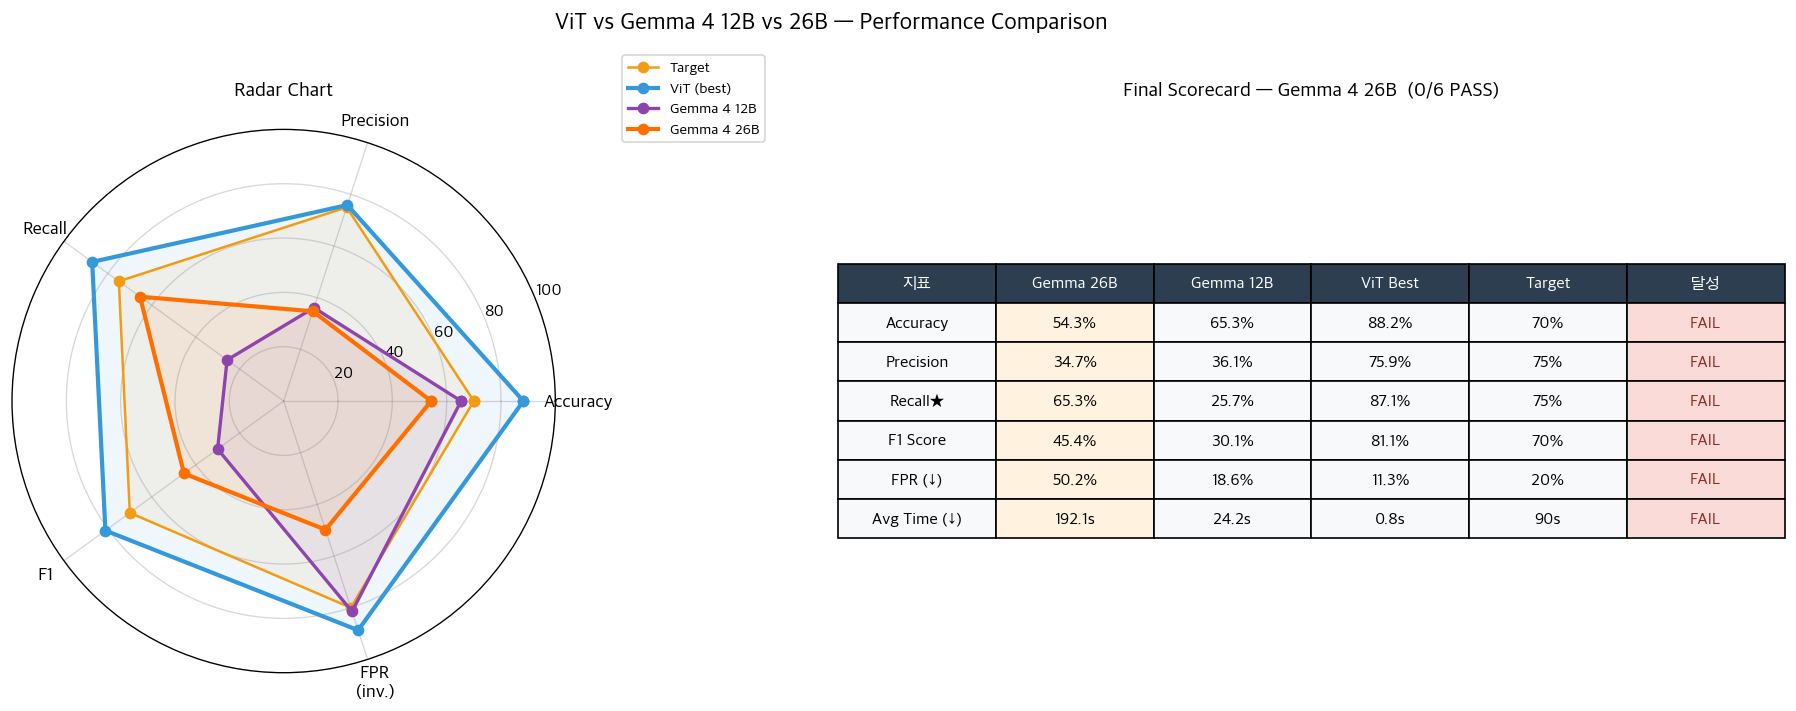

In [10]:
radar_keys   = ['accuracy', 'precision', 'recall', 'f1', 'fpr_inv']
radar_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'FPR\n(inv.)']
N = len(radar_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def to_radar(ref):
    return [ref['accuracy'], ref['precision'], ref['recall'],
            ref['f1'], 100 - ref['fpr']]

vit_r   = to_radar(VIT_REF)
g12b_r  = to_radar(G12B_REF)
g26b_r  = to_radar(m)
tgt_r   = [70, 75, 75, 70, 80]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ViT vs Gemma 4 12B vs 26B — Performance Comparison', fontsize=14, fontweight='bold')

# 레이더
ax = axes[0]
ax.remove()
ax = fig.add_subplot(1, 2, 1, polar=True)

for vals_r, label_r, color_r, lw_r in [
        (tgt_r,  'Target',         COLOR_TARGET, 1.5),
        (vit_r,  'ViT (best)',     COLOR_VIT,    2.5),
        (g12b_r, 'Gemma 4 12B',   COLOR_G12B,   2.0),
        (g26b_r, 'Gemma 4 26B',   COLOR_G26B,   2.5),
    ]:
    v = vals_r + vals_r[:1]
    ax.plot(angles, v, 'o-', linewidth=lw_r, color=color_r, label=label_r)
    ax.fill(angles, v, alpha=0.08, color=color_r)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title('Radar Chart', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax.grid(color='grey', alpha=0.3)

# 종합 스코어카드 테이블
ax2 = axes[1]
ax2.axis('off')
score_metrics = ['accuracy', 'precision', 'recall', 'f1', 'fpr', 'avg_time']
score_labels  = ['Accuracy', 'Precision', 'Recall★', 'F1 Score', 'FPR (↓)', 'Avg Time (↓)']
lower_b       = [False, False, False, False, True, True]
tgt_v         = [TARGET[k] for k in score_metrics]

tdata = []
for lbl, metric, tgt, lower in zip(score_labels, score_metrics, tgt_v, lower_b):
    v26 = m[metric]
    v12 = G12B_REF[metric]
    vvt = VIT_REF[metric]
    ok  = (v26 <= tgt) if lower else (v26 >= tgt)
    unit = 's' if 'time' in metric else '%'
    tdata.append([lbl,
                  f'{v26:.1f}{unit}',
                  f'{v12:.1f}{unit}',
                  f'{vvt:.1f}{unit}',
                  f'{tgt:.0f}{unit}',
                  'PASS' if ok else 'FAIL'])

tbl = ax2.table(
    cellText=tdata,
    colLabels=['지표', 'Gemma 26B', 'Gemma 12B', 'ViT Best', 'Target', '달성'],
    cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)
pass_cnt2 = sum(1 for r in tdata if r[-1] == 'PASS')
for (ri, ci), cell in tbl.get_celld().items():
    if ri == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif ci == 1:
        cell.set_facecolor('#FFF3E0')
    elif ci == 5 and ri > 0:
        t = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if t == 'PASS' else '#fadbd8')
        cell.set_text_props(color='#1e8449' if t == 'PASS' else '#922b21', fontweight='bold')
    else:
        cell.set_facecolor('#f8f9fa')
ax2.set_title(f'Final Scorecard — Gemma 4 26B  ({pass_cnt2}/6 PASS)',
              fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(BENCH_DIR, 'charts', 'gemma4_26b_scorecard.png'),
            bbox_inches='tight', dpi=150)
plt.show()

---
## 10. 결론 및 분석

### 핵심 결과 요약

| 항목 | 결과 |
|---|---|
| **목표 달성** | **1/6** (Avg Time ≤90s 만 통과) |
| **가장 심각한 문제** | FPR 50.2% — Real 이미지 249장 중 **125장을 AI로 오판** |
| **12B 대비** | Recall +25%p 개선, F1 +15%p 개선, **FPR 31.6%p 악화** |
| **ViT 최우수 모델 대비** | 전 지표 열세, 속도 약 220배 느림 |

---

### 원인 분석

**1. 과잉 탐지 편향 (AI 쪽으로 치우침)**  
12B는 REAL로 편향되었던 반면, 26B는 반대로 `AI_GENERATED`로 과잉 판단.  
Real 이미지 249장 중 125장(50.2%)을 AI 생성으로 오탐 — FPR이 급격히 악화.

**2. 모델 크기 ≠ 탐지 정확도**  
파라미터가 커졌다고 탐지 능력이 단순 향상되지 않음.  
26B는 12B보다 이미지 특성을 더 세밀하게 분석하지만,  
현재 프롬프트 기준에서는 오히려 지나치게 의심하는 방향으로 편향됨.

**3. 데이터셋 불균형의 영향**  
AI 101장 vs Real 249장의 불균형에서, 26B는 AI 과탐 편향을 보임.  
임계값(0.5)이 동일하게 적용되어 Real 이미지에서 손실이 큼.

---

### 개선 방향

| 우선순위 | 방향 | 기대 효과 |
|---|---|---|
| **높음** | 임계값을 0.5 → 0.65~0.70으로 올리기 | FPR 감소 (Recall 일부 감수) |
| **높음** | 프롬프트에 "확실한 경우에만 AI_GENERATED" 조건 추가 | 과잉 탐지 억제 |
| **중간** | 12B/26B 앙상블 — 두 모델 모두 AI라고 해야 탐지 | FPR 대폭 감소 |
| **낮음** | GPU 환경에서 26B 재실험 | 속도 문제 해소 |
| **참고** | **ViT 전문 모델 (ai-image-detector-deploy) 사용 권장** | 현 시점 최선 |

---

### 12B vs 26B 종합 비교

| 편향 방향 | 12B (REAL 편향) | 26B (AI 편향) |
|---|---|---|
| AI 탐지 (Recall) | 25.7% | ~51% |
| Real 오탐 (FPR) | 18.6% ✅ | 50.2% ❌ |
| F1 Score | 30.1% | 45.4% |

> 두 모델은 반대 방향으로 편향 — **앙상블 전략이 효과적일 가능성이 높음**

---

### 결론

> **Gemma 4 26B (사전학습 그대로)는 단독 사용 시 AI 이미지 탐지에 적합하지 않습니다.**  
> 12B 대비 Recall·F1은 개선되었으나 FPR이 50%로 치명적으로 높음.  
>  
> 단, **12B(REAL 편향) + 26B(AI 편향)의 앙상블** 조합은 두 편향이 서로 상쇄될 수 있어  
> 유망한 다음 실험 방향입니다. 임계값 조정과 함께 시도 권장.

---
*woochul — InSIGHT Project Gemma 4 26B Baseline Report (2026-05-08)*